# Step 2: Exploratory Data Analysis (EDA)
**Placement Prediction & College Analytics Project**

In this notebook, we perform exploratory data analysis to discover key relationships, trends, and business insights. We will cover:
1. Overall Placement Rate & Summary Metrics
2. Department-wise Placement Analysis
3. CGPA vs Placement (Threshold check)
4. Impact of Internships & Certifications
5. Influence of Communication Skills & Project Counts
6. Salary (Package) Distribution Analysis
7. Top Recruiters Analysis

## 1. Import Libraries and Load Cleaned Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# Load cleaned data
cleaned_path = '../data/cleaned/placement_data_cleaned.csv'
df = pd.read_csv(cleaned_path)
print("Cleaned Data Shape:", df.shape)
df.head()

Cleaned Data Shape: (12000, 22)


,student_id,gender,age,degree,branch,cgpa,backlogs,internships,certifications,coding_skills,...,internship_status,certification_status,placement_status,package_lpa,company_name,has_internship,has_certification,total_skill_score,academic_performance_index,employability_score
0,1,Male,20,BE,Mechanical Engineering,8.40,2,2,2,1,...,Yes,Yes,Placed,8.18,Capgemini,1,1,8,74.0,10.560
1,2,Female,20,BTech,Electrical Engineering,8.60,2,0,5,1,...,No,Yes,Placed,8.41,Cognizant,0,1,7,76.0,6.240
2,3,Male,22,BCA,Electrical Engineering,6.62,3,0,1,1,...,No,Yes,Not Placed,0.00,Unplaced,0,1,8,51.2,5.848
3,4,Male,24,BCA,Data Science,8.01,0,0,4,4,...,No,Yes,Placed,8.69,Capgemini,0,1,13,80.1,8.404
4,5,Male,24,BCA,Electrical Engineering,9.12,2,1,2,4,...,Yes,Yes,Placed,12.08,Adobe,1,1,10,81.2,9.648


## 2. Overall Placement Rate
Let's look at the distribution of placed vs. unplaced students.

Total Students: 12000
Placed: 10937 (91.14%)
Not Placed: 1063 (8.86%)


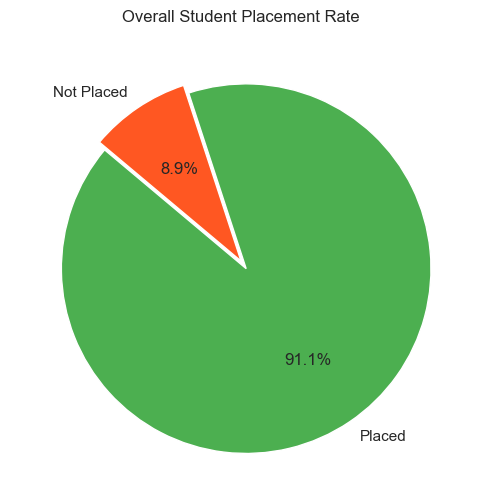

In [2]:
placement_counts = df['placement_status'].value_counts()
placement_pct = df['placement_status'].value_counts(normalize=True) * 100

print("Total Students:", len(df))
print(f"Placed: {placement_counts['Placed']} ({placement_pct['Placed']:.2f}%)")
print(f"Not Placed: {placement_counts['Not Placed']} ({placement_pct['Not Placed']:.2f}%)")

# Visualization
plt.figure(figsize=(6, 6))
plt.pie(placement_counts, labels=placement_counts.index, autopct='%1.1f%%', colors=['#4CAF50', '#FF5722'], startangle=140, explode=(0.05, 0))
plt.title('Overall Student Placement Rate')
plt.show()

## 3. Department-wise Placement
Let's analyze which departments/branches achieve the highest placement rates.

Department-wise Placement Rates (%):
placement_status         Not Placed     Placed
branch                                        
Data Science               8.136615  91.863385
Information Technology     8.286445  91.713555
Artificial Intelligence    8.829365  91.170635
Mechanical Engineering     8.922639  91.077361
Computer Science           9.128205  90.871795
Electrical Engineering     9.843513  90.156487


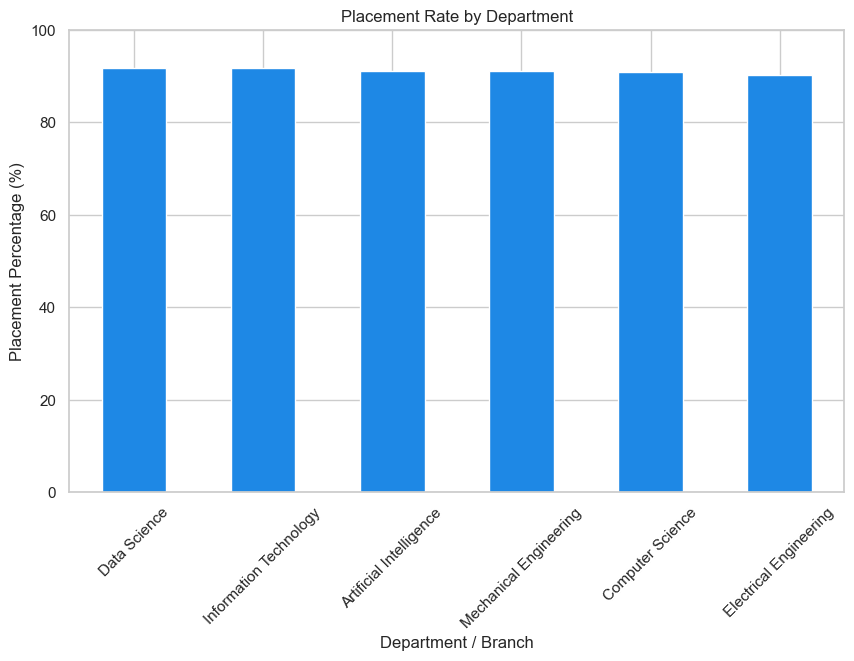

In [3]:
dept_placements = df.groupby('branch')['placement_status'].value_counts(normalize=True).unstack() * 100
dept_placements = dept_placements.sort_values(by='Placed', ascending=False)

print("Department-wise Placement Rates (%):")
print(dept_placements)

# Visualization
dept_placements['Placed'].plot(kind='bar', color='#1E88E5')
plt.title('Placement Rate by Department')
plt.ylabel('Placement Percentage (%)')
plt.xlabel('Department / Branch')
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.show()

## 4. CGPA vs Placement
Let's investigate if there is a minimum CGPA threshold required for placements.

C:\Users\HP\AppData\Local\Temp\ipykernel_17492\1569169779.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='placement_status', y='cgpa', data=df, palette='Set2')


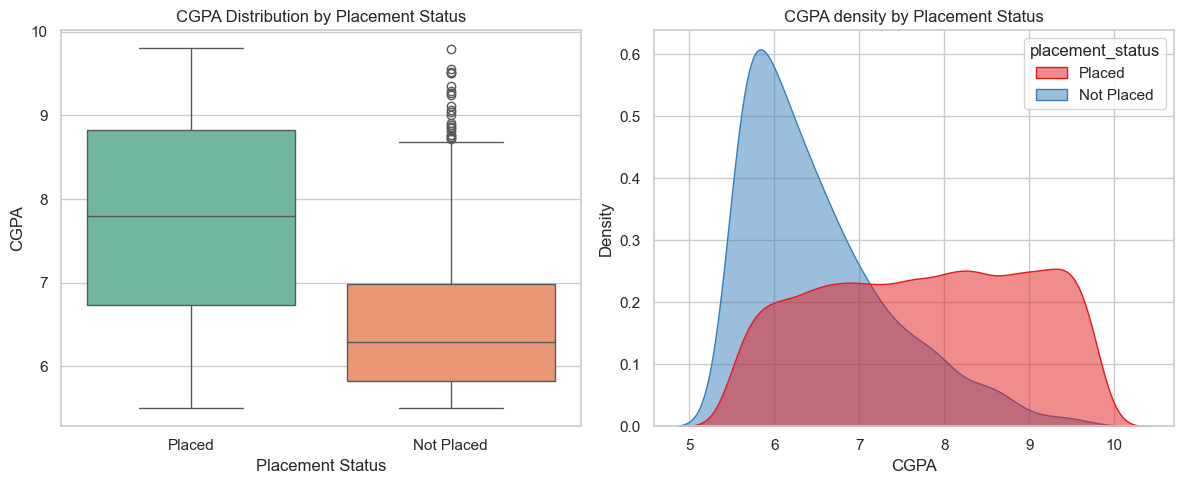

In [4]:
plt.figure(figsize=(12, 5))

# Box Plot
plt.subplot(1, 2, 1)
sns.boxplot(x='placement_status', y='cgpa', data=df, palette='Set2')
plt.title('CGPA Distribution by Placement Status')
plt.xlabel('Placement Status')
plt.ylabel('CGPA')

# KDE Plot
plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x='cgpa', hue='placement_status', fill=True, common_norm=False, palette='Set1', alpha=0.5)
plt.title('CGPA density by Placement Status')
plt.xlabel('CGPA')

plt.tight_layout()
plt.show()

## 5. Internship Impact
Let's check if completing internships boosts placement rates.

Placement Rate based on Internships Done:
placement_status   Not Placed     Placed
internship_status                       
No                  14.233697  85.766303
Yes                  7.049783  92.950217


C:\Users\HP\AppData\Local\Temp\ipykernel_17492\1675153644.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=df['internship_status'], y=(df['placement_status'] == 'Placed').astype(int) * 100, ci=None, palette='viridis')
C:\Users\HP\AppData\Local\Temp\ipykernel_17492\1675153644.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['internship_status'], y=(df['placement_status'] == 'Placed').astype(int) * 100, ci=None, palette='viridis')


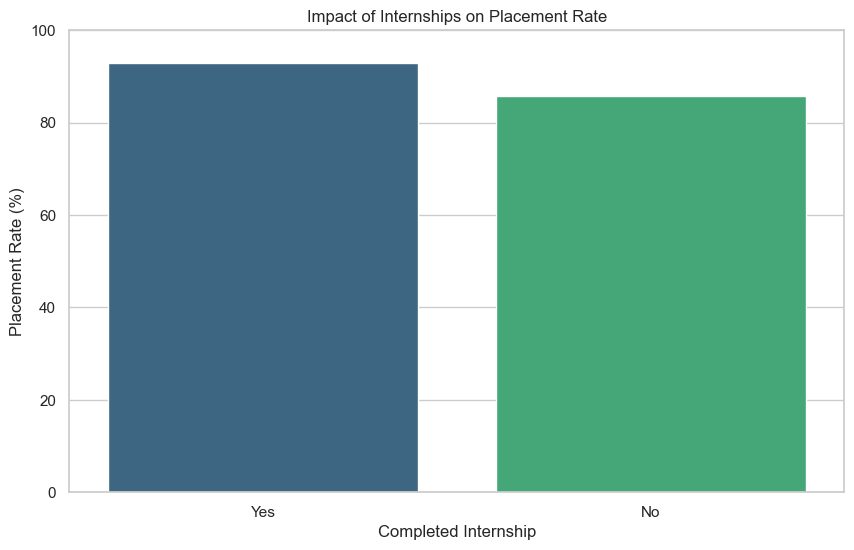

In [5]:
internship_rates = df.groupby('internship_status')['placement_status'].value_counts(normalize=True).unstack() * 100
print("Placement Rate based on Internships Done:")
print(internship_rates)

sns.barplot(x=df['internship_status'], y=(df['placement_status'] == 'Placed').astype(int) * 100, ci=None, palette='viridis')
plt.title('Impact of Internships on Placement Rate')
plt.ylabel('Placement Rate (%)')
plt.xlabel('Completed Internship')
plt.ylim(0, 100)
plt.show()

## 6. Certifications Analysis
Do certifications help students get placed?

C:\Users\HP\AppData\Local\Temp\ipykernel_17492\1377402672.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='certifications', y=(df['placement_status'] == 'Placed').astype(int) * 100, data=df, ci=None, palette='crest')
C:\Users\HP\AppData\Local\Temp\ipykernel_17492\1377402672.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='certifications', y=(df['placement_status'] == 'Placed').astype(int) * 100, data=df, ci=None, palette='crest')


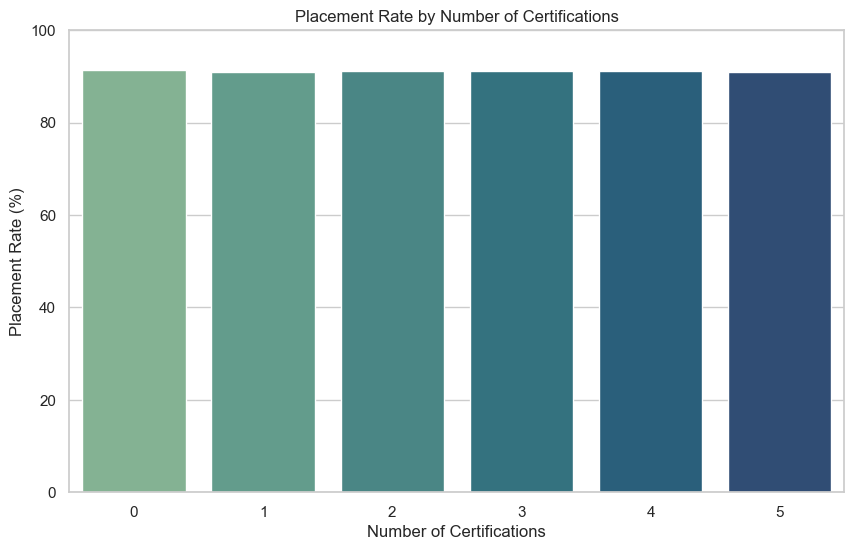

In [6]:
sns.barplot(x='certifications', y=(df['placement_status'] == 'Placed').astype(int) * 100, data=df, ci=None, palette='crest')
plt.title('Placement Rate by Number of Certifications')
plt.ylabel('Placement Rate (%)')
plt.xlabel('Number of Certifications')
plt.ylim(0, 100)
plt.show()

## 7. Communication Skills vs Placement
Let's see if students with stronger communication scores secure placements more often.

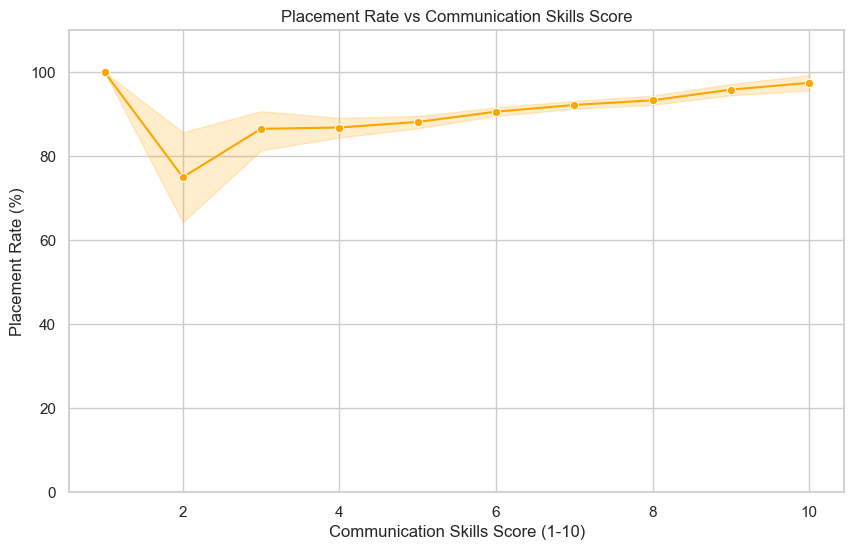

In [7]:
sns.lineplot(x='communication_skills', y=(df['placement_status'] == 'Placed').astype(int) * 100, data=df, color='orange', marker='o')
plt.title('Placement Rate vs Communication Skills Score')
plt.ylabel('Placement Rate (%)')
plt.xlabel('Communication Skills Score (1-10)')
plt.ylim(0, 110)
plt.show()

## 8. Project Count Analysis (Salary Package Impact)
Do students with more projects receive higher salary offers?

C:\Users\HP\AppData\Local\Temp\ipykernel_17492\351514896.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='project_count', y='package_lpa', data=placed_df, palette='flare')


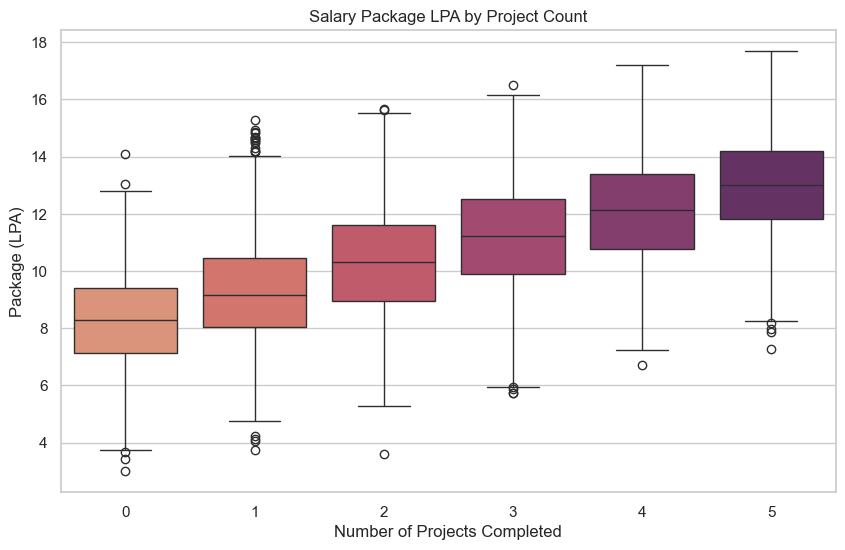

In [8]:
placed_df = df[df['placement_status'] == 'Placed']

sns.boxplot(x='project_count', y='package_lpa', data=placed_df, palette='flare')
plt.title('Salary Package LPA by Project Count')
plt.ylabel('Package (LPA)')
plt.xlabel('Number of Projects Completed')
plt.show()

## 9. Salary Distribution (Placed Students Only)
Let's look at the average, highest, and median packages offered.

Average Salary Package: 10.85 LPA
Median Salary Package: 10.85 LPA
Highest Salary Package: 17.69 LPA


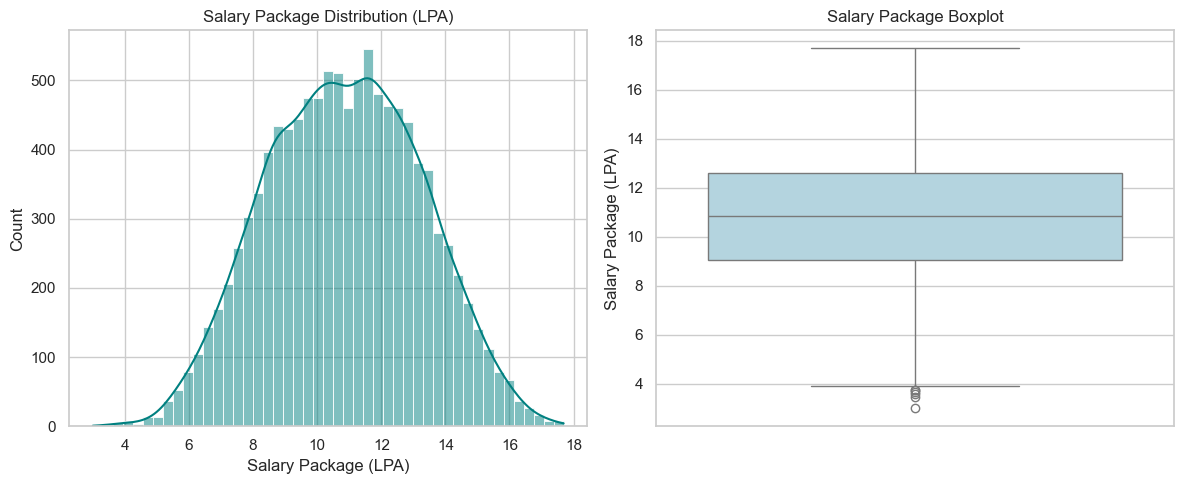

In [9]:
avg_pkg = placed_df['package_lpa'].mean()
median_pkg = placed_df['package_lpa'].median()
max_pkg = placed_df['package_lpa'].max()

print(f"Average Salary Package: {avg_pkg:.2f} LPA")
print(f"Median Salary Package: {median_pkg:.2f} LPA")
print(f"Highest Salary Package: {max_pkg:.2f} LPA")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(placed_df['package_lpa'], kde=True, color='teal')
plt.title('Salary Package Distribution (LPA)')
plt.xlabel('Salary Package (LPA)')

plt.subplot(1, 2, 2)
sns.boxplot(y=placed_df['package_lpa'], color='lightblue')
plt.title('Salary Package Boxplot')
plt.ylabel('Salary Package (LPA)')

plt.tight_layout()
plt.show()

## 10. Recruiter Analysis
Who are the top hiring partners, and what is their average package offer?

     company_name  Hires  Avg_Package_LPA
6         Infosys   1629         9.933118
0       Accenture   1601         9.969144
4       Cognizant   1599         9.941257
3       Capgemini   1558         9.917741
7            Meta    751        13.557949
8       Microsoft    742        13.453827
1           Adobe    740        13.584068
5          Google    719        13.532990
2          Amazon    679        13.482504
10  Tech Mahindra    350         6.608114
11          Wipro    300         6.558333
9             TCS    269         6.591413


C:\Users\HP\AppData\Local\Temp\ipykernel_17492\379784063.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Hires', y='company_name', data=recruiter_summary, palette='Blues_r')
C:\Users\HP\AppData\Local\Temp\ipykernel_17492\379784063.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Avg_Package_LPA', y='company_name', data=recruiter_summary.sort_values('Avg_Package_LPA', ascending=False), palette='Greens_r')


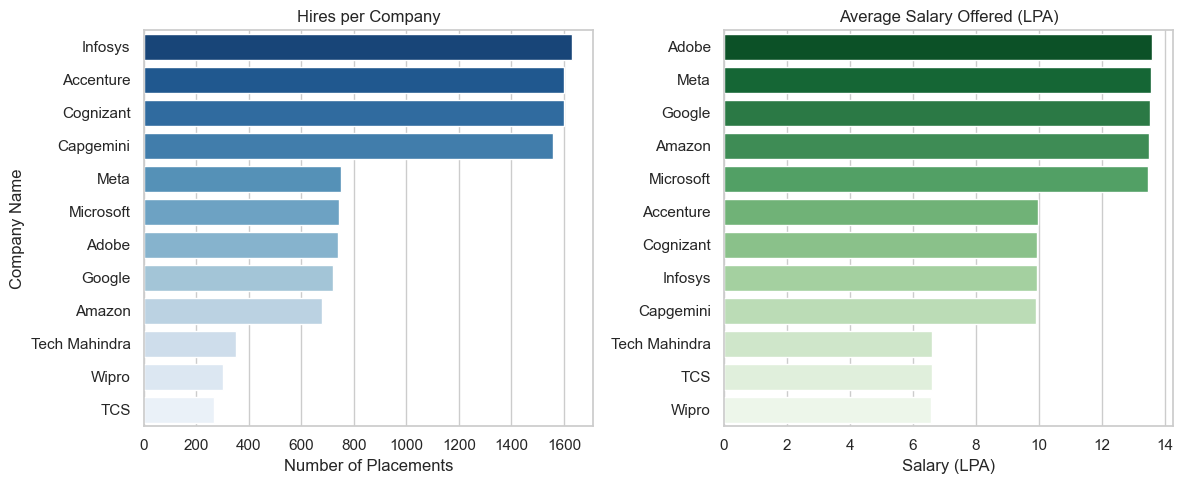

In [10]:
recruiter_summary = placed_df.groupby('company_name').agg(
    Hires=('student_id', 'count'),
    Avg_Package_LPA=('package_lpa', 'mean')
).reset_index().sort_values(by='Hires', ascending=False)

print(recruiter_summary)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x='Hires', y='company_name', data=recruiter_summary, palette='Blues_r')
plt.title('Hires per Company')
plt.xlabel('Number of Placements')
plt.ylabel('Company Name')

plt.subplot(1, 2, 2)
sns.barplot(x='Avg_Package_LPA', y='company_name', data=recruiter_summary.sort_values('Avg_Package_LPA', ascending=False), palette='Greens_r')
plt.title('Average Salary Offered (LPA)')
plt.xlabel('Salary (LPA)')
plt.ylabel('')

plt.tight_layout()
plt.show()